# Comprehensive Comparison: Sharpe vs QUBO vs HRP

This notebook loads results from all three portfolio optimization methods (Sharpe, QUBO, HRP) and compares them side by side across all periods.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 11

# Create artifacts directory for saving plots
artifacts_dir = '../../artifacts'
os.makedirs(artifacts_dir, exist_ok=True)
print(f"Artifacts directory: {artifacts_dir}")

Artifacts directory: ../../artifacts


## Data Loading Functions

In [2]:
def load_pickle_result(file_path):
    """Load a single pickle result file."""
    try:
        with open(file_path, 'rb') as f:
            return pickle.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def parse_hrp_filename(filename):
    """Parse HRP result filename to extract metadata."""
    basename = os.path.basename(filename)
    parts = basename.replace('.pkl', '').replace('results_', '').split('_')
    
    period = None
    period_idx = None
    
    for i in range(len(parts) - 1, -1, -1):
        try:
            period = int(parts[i])
            period_idx = i
            break
        except ValueError:
            continue
    
    if period is None:
        return None, None
    
    solver = '_'.join(parts[:period_idx])
    return period, solver

def parse_sharpe_filename(filename):
    """Parse Sharpe optimization result filename."""
    basename = os.path.basename(filename)
    parts = basename.replace('.pkl', '').replace('results_', '').split('_')
    
    period = None
    period_idx = None
    for i in range(len(parts) - 1, -1, -1):
        try:
            period = int(parts[i])
            period_idx = i
            break
        except ValueError:
            continue
    
    if period is None:
        return None, None, None
    
    prefix_parts = parts[:period_idx]
    if len(prefix_parts) == 0:
        return None, None, None
    
    known_solvers = {'ew', 'ga', 'bf', 'quantum'}
    
    if prefix_parts[0] in known_solvers:
        dataset = 'wide'
        solver = prefix_parts[0]
    elif len(prefix_parts) >= 2 and prefix_parts[-1] in known_solvers:
        dataset = '_'.join(prefix_parts[:-1])
        solver = prefix_parts[-1]
    else:
        dataset = 'wide'
        solver = '_'.join(prefix_parts).replace('_', '-')
    
    return dataset, period, solver

def parse_qubo_filename(filename):
    """Parse QUBO optimization result filename."""
    basename = os.path.basename(filename)
    parts = basename.replace('.pkl', '').replace('results_', '').split('_')
    
    period = None
    period_idx = None
    for i in range(len(parts) - 1, -1, -1):
        try:
            period = int(parts[i])
            period_idx = i
            break
        except ValueError:
            continue
    
    if period is None:
        return None, None, None
    
    prefix_parts = parts[:period_idx]
    if len(prefix_parts) == 0:
        return None, None, None
    
    known_solvers = {'ew', 'ga', 'bf'}
    known_multi_word_solvers = {'dwave_cqm', 'dwave_nl'}
    
    if prefix_parts[0] in known_solvers:
        dataset = 'wide'
        solver = prefix_parts[0]
    elif len(prefix_parts) >= 2:
        potential_solver = '_'.join(prefix_parts)
        if potential_solver in known_multi_word_solvers:
            dataset = 'wide'
            solver = potential_solver
        elif prefix_parts[-1] in known_solvers:
            dataset = '_'.join(prefix_parts[:-1])
            solver = prefix_parts[-1]
        elif len(prefix_parts) >= 3 and '_'.join(prefix_parts[-2:]) in known_multi_word_solvers:
            dataset = '_'.join(prefix_parts[:-2])
            solver = '_'.join(prefix_parts[-2:])
        else:
            dataset = '_'.join(prefix_parts[:-1])
            solver = prefix_parts[-1]
    else:
        dataset = 'wide'
        solver = prefix_parts[0]
    
    return dataset, period, solver

def load_method_results(result_dir, parse_fn, has_dataset=True):
    """Load results from a method directory."""
    results = []
    files = glob.glob(os.path.join(result_dir, '*.pkl'))
    print(f"Found {len(files)} files in {result_dir}")
    
    for file_path in files:
        if has_dataset:
            dataset, period, solver = parse_fn(file_path)
            if dataset is None or dataset != 'wide':
                continue
        else:
            period, solver = parse_fn(file_path)
            if period is None:
                continue
        
        data = load_pickle_result(file_path)
        if data is not None:
            portfolio_returns = data.get('portfolio_cumulative_returns', [])
            execution_time = data.get('total_run_time', 0)
            start_date = data.get('start_date')
            end_date = data.get('end_date')
            
            final_return = None
            if portfolio_returns is not None:
                try:
                    if hasattr(portfolio_returns, '__len__') and len(portfolio_returns) > 0:
                        final_return = portfolio_returns[-1]
                except:
                    pass
            
            results.append({
                'period': period,
                'solver': solver,
                'portfolio_returns': portfolio_returns,
                'final_return': final_return,
                'execution_time': execution_time,
                'start_date': start_date,
                'end_date': end_date
            })
    
    return results

## Load All Results

In [3]:
print("=" * 100)
print("LOADING ALL OPTIMIZATION RESULTS")
print("=" * 100)

# Load results from each method
sharpe_results = load_method_results('../../results/sharpe_optimization', parse_sharpe_filename, has_dataset=True)
qubo_results = load_method_results('../../results/qubo', parse_qubo_filename, has_dataset=True)
hrp_results = load_method_results('../../results/hrp', parse_hrp_filename, has_dataset=False)

df_sharpe = pd.DataFrame(sharpe_results)
df_qubo = pd.DataFrame(qubo_results)
df_hrp = pd.DataFrame(hrp_results)

print(f"\nLoaded {len(df_sharpe)} Sharpe results, solvers: {sorted(df_sharpe['solver'].unique())}")
print(f"Loaded {len(df_qubo)} QUBO results, solvers: {sorted(df_qubo['solver'].unique())}")
print(f"Loaded {len(df_hrp)} HRP results, solvers: {sorted(df_hrp['solver'].unique())}")

LOADING ALL OPTIMIZATION RESULTS
Found 54 files in ../../results/sharpe_optimization
Found 58 files in ../../results/qubo
Found 20 files in ../../results/hrp

Loaded 33 Sharpe results, solvers: ['bf', 'dwave-nl', 'ew', 'ga']
Loaded 38 QUBO results, solvers: ['bf', 'dwave_cqm', 'ew', 'ga']
Loaded 20 HRP results, solvers: ['ew', 'hrp_pearson_ward']


## Build Comparison Dataset

In [4]:
sharpe_solver_names = {
    'ew': 'Equal Weights',
    'ga': 'Genetic Algorithm',
    'bf': 'Scipy SLSQP',
    'dwave-nl': 'D-Wave Nonlinear'
}

qubo_solver_names = {
    'ew': 'Equal Weights',
    'ga': 'Genetic Algorithm',
    'bf': 'Scipy SLSQP',
    'dwave_cqm': 'D-Wave CQM'
}

comparison_data = []

# Add Sharpe results (exclude ew — it's a shared baseline)
for _, row in df_sharpe.iterrows():
    solver = row['solver']
    if solver in ['bf', 'dwave-nl', 'ga']:
        solver_name = sharpe_solver_names.get(solver, solver)
        comparison_data.append({
            'method_solver': f"Sharpe - {solver_name}",
            'method': 'Sharpe',
            'period': row['period'],
            'portfolio_returns': row['portfolio_returns'],
            'final_return': row['final_return'],
            'execution_time': row['execution_time'],
            'start_date': row['start_date'],
            'end_date': row['end_date']
        })

# Add QUBO results (exclude ew)
for _, row in df_qubo.iterrows():
    solver = row['solver']
    if solver in ['bf', 'dwave_cqm', 'ga']:
        solver_name = qubo_solver_names.get(solver, solver)
        comparison_data.append({
            'method_solver': f"QUBO - {solver_name}",
            'method': 'QUBO',
            'period': row['period'],
            'portfolio_returns': row['portfolio_returns'],
            'final_return': row['final_return'],
            'execution_time': row['execution_time'],
            'start_date': row['start_date'],
            'end_date': row['end_date']
        })

# Add HRP results
for _, row in df_hrp.iterrows():
    solver = row['solver']
    if solver == 'hrp_pearson_ward':
        comparison_data.append({
            'method_solver': 'HRP (Pearson + Ward)',
            'method': 'HRP',
            'period': row['period'],
            'portfolio_returns': row['portfolio_returns'],
            'final_return': row['final_return'],
            'execution_time': row['execution_time'],
            'start_date': row['start_date'],
            'end_date': row['end_date']
        })

df_comparison = pd.DataFrame(comparison_data)

print(f"Total methods in comparison: {len(df_comparison['method_solver'].unique())}")
print(f"Methods: {sorted(df_comparison['method_solver'].unique())}")

Total methods in comparison: 7
Methods: ['HRP (Pearson + Ward)', 'QUBO - D-Wave CQM', 'QUBO - Genetic Algorithm', 'QUBO - Scipy SLSQP', 'Sharpe - D-Wave Nonlinear', 'Sharpe - Genetic Algorithm', 'Sharpe - Scipy SLSQP']


## Cumulative Returns - All Periods


PLOTTING COMPREHENSIVE COMPARISON - ALL PERIODS



Saved: comprehensive_comparison_all_methods_all_periods.png


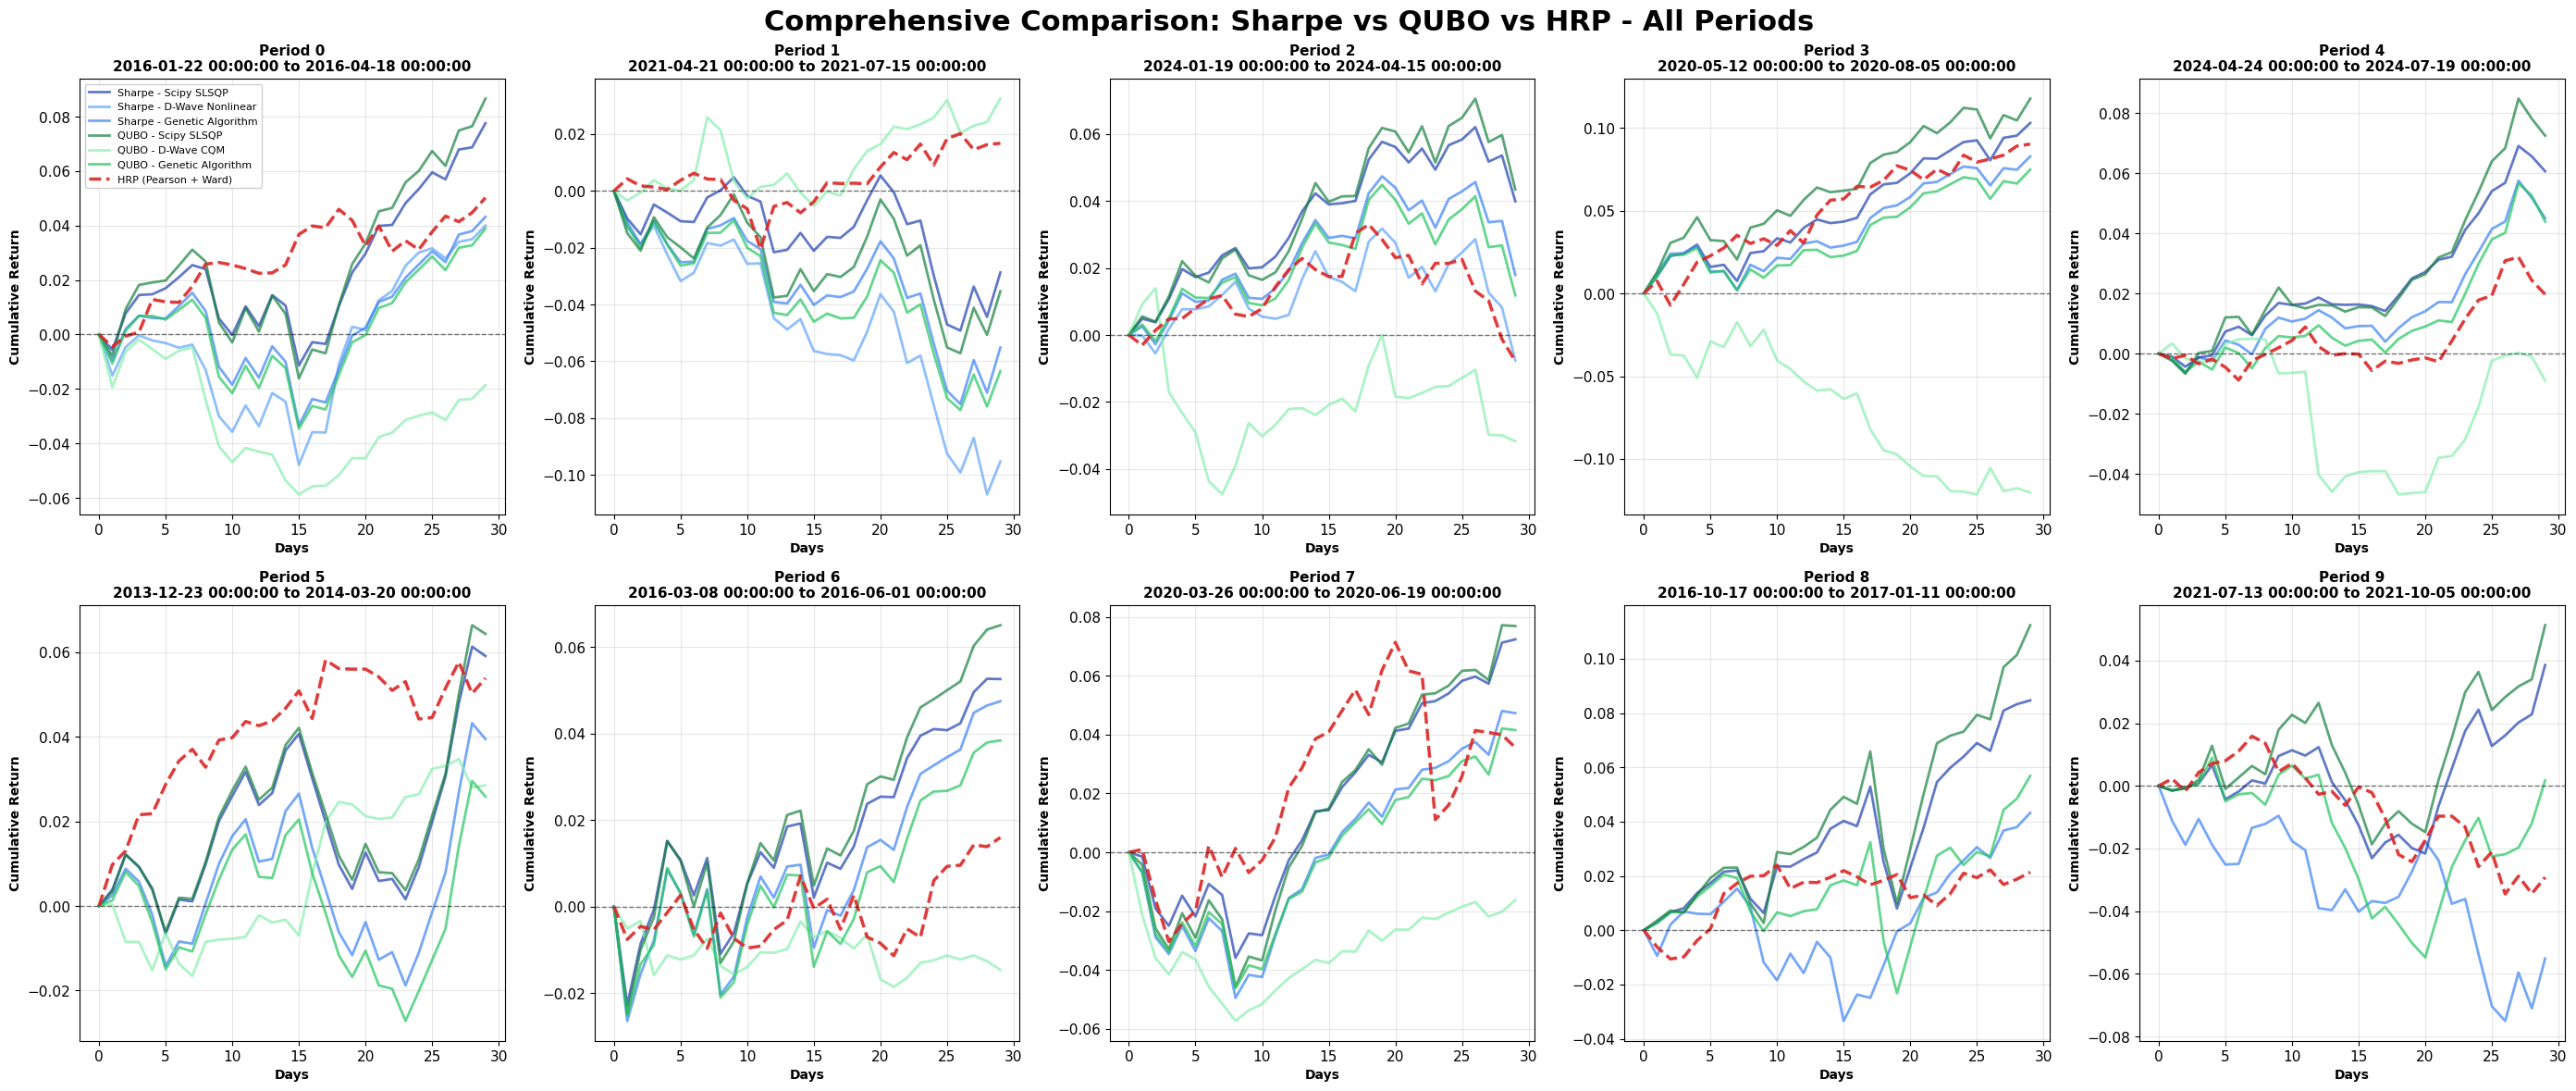

In [5]:
# Comprehensive comparison plot - all periods
print("\n" + "=" * 100)
print("PLOTTING COMPREHENSIVE COMPARISON - ALL PERIODS")
print("=" * 100)

method_colors = {
    'Sharpe - Scipy SLSQP': '#1E40AF',
    'Sharpe - Genetic Algorithm': '#3B82F6',
    'Sharpe - D-Wave Nonlinear': '#60A5FA',
    'QUBO - Scipy SLSQP': '#15803D',
    'QUBO - Genetic Algorithm': '#22C55E',
    'QUBO - D-Wave CQM': '#86EFAC',
    'HRP (Pearson + Ward)': '#DC2626'
}

fig, axes = plt.subplots(2, 5, figsize=(28, 12))
fig.suptitle('Comprehensive Comparison: Sharpe vs QUBO vs HRP - All Periods', fontsize=22, fontweight='bold')
axes = axes.flatten()

periods = sorted(df_comparison['period'].unique())

for idx, period in enumerate(periods):
    ax = axes[idx]
    period_data = df_comparison[df_comparison['period'] == period]
    
    for _, row in period_data.iterrows():
        method_solver = row['method_solver']
        portfolio_returns = row['portfolio_returns']
        start_date = row['start_date']
        end_date = row['end_date']
        
        if portfolio_returns is not None and hasattr(portfolio_returns, '__len__'):
            returns_array = np.array(portfolio_returns)
            if len(returns_array) > 0:
                time_axis = np.arange(len(returns_array))
                color = method_colors.get(method_solver, '#000000')
                linestyle = '--' if 'HRP' in method_solver else '-'
                linewidth = 2.5 if 'HRP' in method_solver else 2
                alpha = 0.9 if 'HRP' in method_solver else 0.7
                
                ax.plot(time_axis, returns_array, 
                       label=method_solver, 
                       color=color, 
                       linewidth=linewidth,
                       linestyle=linestyle,
                       alpha=alpha)
    
    ax.set_title(f'Period {period}\n{start_date} to {end_date}', 
                fontweight='bold', fontsize=11)
    ax.set_xlabel('Days', fontweight='bold', fontsize=10)
    ax.set_ylabel('Cumulative Return', fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    if idx == 0:
        ax.legend(loc='best', fontsize=8, framealpha=0.95, ncol=1)

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'comprehensive_comparison_all_methods_all_periods.png'), dpi=300, bbox_inches='tight')
print("\nSaved: comprehensive_comparison_all_methods_all_periods.png")
plt.show()

## Period-by-Period Summary and Overall Comparison

In [6]:
# Period-by-period summary
print("\n" + "=" * 100)
print("COMPREHENSIVE PERIOD-BY-PERIOD SUMMARY")
print("=" * 100)

for period in periods:
    period_data = df_comparison[df_comparison['period'] == period]
    valid_data = period_data[period_data['final_return'].notna()]
    
    if len(valid_data) > 0:
        print(f"\nPeriod {period}:")
        print("-" * 70)
        
        sorted_data = valid_data.sort_values('final_return', ascending=False)
        
        for _, row in sorted_data.iterrows():
            method_solver = row['method_solver']
            final_return = row['final_return']
            exec_time = row['execution_time']
            print(f"  {method_solver:30s}: Return = {final_return:>8.4f} ({final_return*100:>6.2f}%), Time = {exec_time:>7.2f}s")
        
        best = sorted_data.iloc[0]
        print(f"\n  \u2713 Best: {best['method_solver']} ({best['final_return']:.4f})")

# Overall comparison statistics
print("\n" + "=" * 100)
print("OVERALL AVERAGE PERFORMANCE COMPARISON")
print("=" * 100)

comparison_stats = []
for method_solver in sorted(df_comparison['method_solver'].unique()):
    method_data = df_comparison[df_comparison['method_solver'] == method_solver]
    valid_data = method_data[method_data['final_return'].notna()]
    
    if len(valid_data) > 0:
        avg_return = valid_data['final_return'].mean()
        std_return = valid_data['final_return'].std()
        avg_time = valid_data['execution_time'].mean()
        n_periods = len(valid_data)
        
        comparison_stats.append({
            'Method': method_solver,
            'Avg_Return': avg_return,
            'Std_Return': std_return,
            'Avg_Time': avg_time,
            'N_Periods': n_periods
        })

df_comparison_stats = pd.DataFrame(comparison_stats)
df_comparison_stats = df_comparison_stats.sort_values('Avg_Return', ascending=False)

print("\nComprehensive Performance Summary (sorted by average return):")
print("-" * 100)
print(df_comparison_stats.to_string(index=False))

# Key findings
print("\n" + "=" * 100)
print("KEY FINDINGS")
print("=" * 100)

best_return = df_comparison_stats.iloc[0]
print(f"\n\u2713 Best Average Return: {best_return['Method']}")
print(f"  Return: {best_return['Avg_Return']:.4f} \u00b1 {best_return['Std_Return']:.4f}")
print(f"  Avg Time: {best_return['Avg_Time']:.2f}s")

fastest = df_comparison_stats.loc[df_comparison_stats['Avg_Time'].idxmin()]
print(f"\n\u2713 Fastest: {fastest['Method']}")
print(f"  Avg Time: {fastest['Avg_Time']:.2f}s")
print(f"  Return: {fastest['Avg_Return']:.4f} \u00b1 {fastest['Std_Return']:.4f}")

# Compare by method category
print("\n" + "=" * 100)
print("COMPARISON BY METHOD CATEGORY")
print("=" * 100)

for method in ['Sharpe', 'QUBO', 'HRP']:
    method_subset = df_comparison_stats[df_comparison_stats['Method'].str.contains(method)]
    if len(method_subset) > 0:
        print(f"\n{method}:")
        print("-" * 50)
        for _, row in method_subset.iterrows():
            print(f"  {row['Method']:30s}: {row['Avg_Return']:.4f} \u00b1 {row['Std_Return']:.4f}")
        
        best_in_category = method_subset.iloc[0]
        print(f"  \u2192 Best {method}: {best_in_category['Method']}")


COMPREHENSIVE PERIOD-BY-PERIOD SUMMARY

Period 0:
----------------------------------------------------------------------
  QUBO - Scipy SLSQP            : Return =   0.0866 (  8.66%), Time = 3343.62s
  Sharpe - Scipy SLSQP          : Return =   0.0776 (  7.76%), Time = 2299.47s
  HRP (Pearson + Ward)          : Return =   0.0502 (  5.02%), Time =   17.63s
  Sharpe - Genetic Algorithm    : Return =   0.0432 (  4.32%), Time = 4359.36s
  Sharpe - D-Wave Nonlinear     : Return =   0.0400 (  4.00%), Time = 6732.33s
  QUBO - Genetic Algorithm      : Return =   0.0389 (  3.89%), Time = 4346.44s
  QUBO - D-Wave CQM             : Return =  -0.0186 ( -1.86%), Time = 9518.25s

  ✓ Best: QUBO - Scipy SLSQP (0.0866)

Period 1:
----------------------------------------------------------------------
  QUBO - D-Wave CQM             : Return =   0.0325 (  3.25%), Time = 8257.90s
  HRP (Pearson + Ward)          : Return =   0.0168 (  1.68%), Time =   18.00s
  Sharpe - Scipy SLSQP          : Return =  -0

## Distribution Plots: Returns and Execution Time by Method

Saved: comprehensive_distplots_returns_time.png


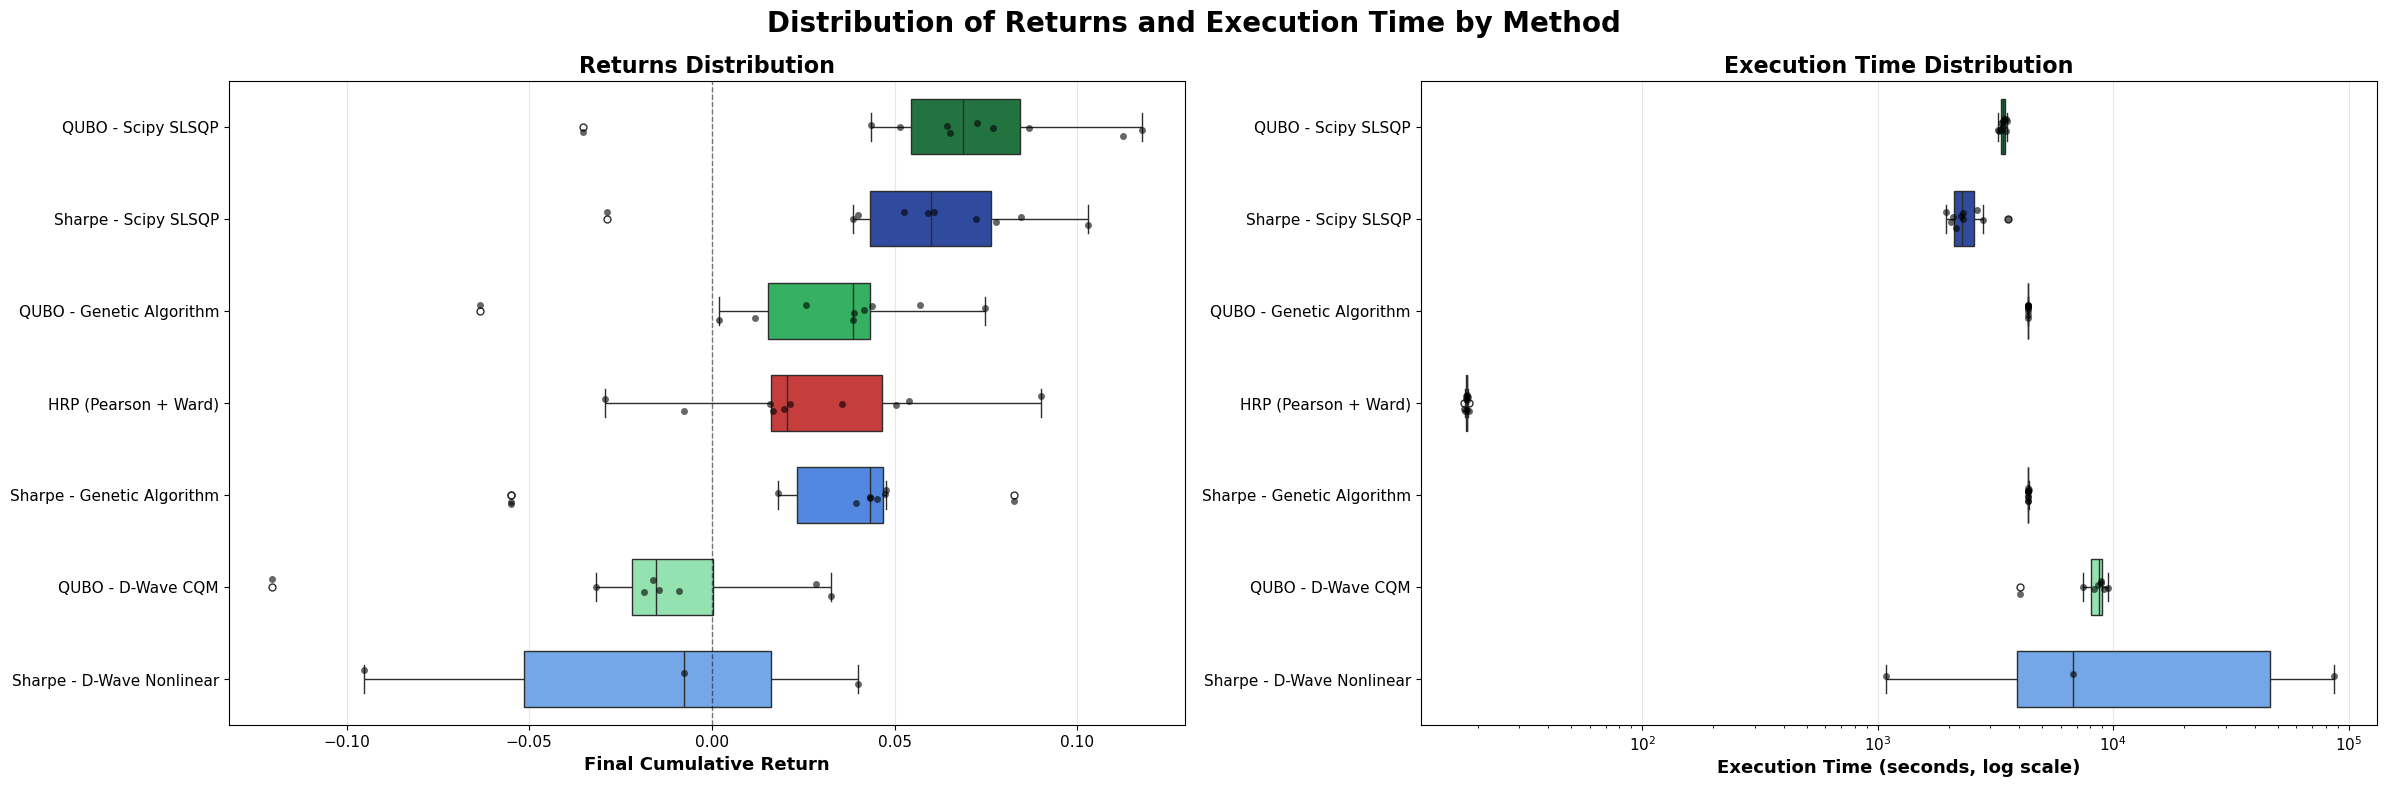

In [7]:
# Distribution of Returns by Method
method_colors = {
    'Sharpe - Scipy SLSQP': '#1E40AF',
    'Sharpe - Genetic Algorithm': '#3B82F6',
    'Sharpe - D-Wave Nonlinear': '#60A5FA',
    'QUBO - Scipy SLSQP': '#15803D',
    'QUBO - Genetic Algorithm': '#22C55E',
    'QUBO - D-Wave CQM': '#86EFAC',
    'HRP (Pearson + Ward)': '#DC2626'
}

# Sort methods by average return for consistent ordering
method_order = df_comparison_stats['Method'].tolist()
valid_comparison = df_comparison[df_comparison['final_return'].notna()].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))
fig.suptitle('Distribution of Returns and Execution Time by Method', fontsize=20, fontweight='bold')

# --- Returns Distribution ---
palette_returns = [method_colors.get(m, '#000000') for m in method_order]

sns.boxplot(
    data=valid_comparison,
    x='final_return',
    y='method_solver',
    order=method_order,
    palette=palette_returns,
    width=0.6,
    fliersize=5,
    ax=ax1
)
sns.stripplot(
    data=valid_comparison,
    x='final_return',
    y='method_solver',
    order=method_order,
    color='black',
    size=5,
    alpha=0.6,
    ax=ax1
)

ax1.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('Final Cumulative Return', fontweight='bold', fontsize=13)
ax1.set_ylabel('')
ax1.set_title('Returns Distribution', fontweight='bold', fontsize=16)
ax1.grid(True, alpha=0.3, axis='x')
ax1.tick_params(axis='y', labelsize=11)

# --- Execution Time Distribution ---
palette_time = [method_colors.get(m, '#000000') for m in method_order]

sns.boxplot(
    data=valid_comparison,
    x='execution_time',
    y='method_solver',
    order=method_order,
    palette=palette_time,
    width=0.6,
    fliersize=5,
    ax=ax2
)
sns.stripplot(
    data=valid_comparison,
    x='execution_time',
    y='method_solver',
    order=method_order,
    color='black',
    size=5,
    alpha=0.6,
    ax=ax2
)

ax2.set_xscale('log')
ax2.set_xlabel('Execution Time (seconds, log scale)', fontweight='bold', fontsize=13)
ax2.set_ylabel('')
ax2.set_title('Execution Time Distribution', fontweight='bold', fontsize=16)
ax2.grid(True, alpha=0.3, axis='x')
ax2.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'comprehensive_distplots_returns_time.png'), dpi=300, bbox_inches='tight')
print("Saved: comprehensive_distplots_returns_time.png")
plt.show()